# Loan Approval Prediction Using Decision Tree

This project aims to predict whether a loan application will be approved or rejected using a Decision Tree Classification algorithm.

## Objective

The objective of this project is to build a machine learning classification model that predicts loan approval status based on applicant and loan-related information.

The target variable is `Loan_Status`, where:

- `Y` represents an approved loan.
- `N` represents a rejected loan.

## Dataset Description

The dataset consists of three files:

- `train.csv` – Contains the training data along with the target variable `Loan_Status`.
- `test.csv` – Contains unseen data for which loan approval predictions are required.
- `Sample_Submission.csv` – Provides the required format for the final prediction submission.

The training dataset contains 614 records and 13 columns, while the test dataset contains 367 records and 12 columns.

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [2]:
train = pd.read_csv(r"C:\Users\reju6\Downloads\archive (2)\Training Dataset.csv")
test = pd.read_csv(r"C:\Users\reju6\Downloads\archive (2)\Test Dataset.csv")
sample = pd.read_csv(r"C:\Users\reju6\Downloads\archive (2)\Sample_Submission.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)

train.head()

Train shape: (614, 13)
Test shape: (367, 12)


,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [3]:
print(train.info())
print(train.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB
None
Loan_ID               0
Gender               13
Married               3
Dependents           15
Education  

In [4]:
X = train.drop("Loan_Status", axis=1)
y = train["Loan_Status"]

In [5]:
X = X.drop("Loan_ID", axis=1)

test_ids = test["Loan_ID"]
X_test = test.drop("Loan_ID", axis=1)

In [8]:
#numerical values
numeric_cols = X.select_dtypes(include=np.number).columns

for col in numeric_cols:
    X[col] = X[col].fillna(X[col].median())
    X_test[col] = X_test[col].fillna(X[col].median())

In [9]:
categorical_cols = X.select_dtypes(include="object").columns

for col in categorical_cols:
    X[col] = X[col].fillna(X[col].mode()[0])
    X_test[col] = X_test[col].fillna(X[col].mode()[0])

In [10]:
#Convert categorical data to numbers


X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=categorical_cols, drop_first=True)

In [11]:
#Convert target
y = y.map({"Y": 1, "N": 0})

In [12]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [19]:
#train decision tree
model = DecisionTreeClassifier(
   max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,4
,min_samples_split,10
,min_samples_leaf,5
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [20]:
y_pred = model.predict(X_val)

print("Accuracy:", accuracy_score(y_val, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.8211382113821138

Confusion Matrix:
[[24 14]
 [ 8 77]]

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.63      0.69        38
           1       0.85      0.91      0.88        85

    accuracy                           0.82       123
   macro avg       0.80      0.77      0.78       123
weighted avg       0.82      0.82      0.82       123



In [21]:
final_model = DecisionTreeClassifier(
    random_state=42
)

final_model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [22]:
test_predictions = final_model.predict(X_test)

In [23]:
test_predictions = np.where(
    test_predictions == 1,
    "Y",
    "N"
)

In [24]:
submission = pd.DataFrame({
    "Loan_ID": test_ids,
    "Loan_Status": test_predictions
})

submission.to_csv("submission.csv", index=False)

print(submission.head())

    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y


In [25]:
#tuning
from sklearn.metrics import accuracy_score

depths = [2, 3, 4, 5, 6, 7, 8, 10]

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )

    model.fit(X_train, y_train)

    pred = model.predict(X_val)

    print(
        "max_depth =", depth,
        "Accuracy =", accuracy_score(y_val, pred)
    )

max_depth = 2 Accuracy = 0.8536585365853658
max_depth = 3 Accuracy = 0.8455284552845529
max_depth = 4 Accuracy = 0.8455284552845529
max_depth = 5 Accuracy = 0.8292682926829268
max_depth = 6 Accuracy = 0.8292682926829268
max_depth = 7 Accuracy = 0.7886178861788617
max_depth = 8 Accuracy = 0.7967479674796748
max_depth = 10 Accuracy = 0.7723577235772358


In [26]:
#best model
best_depth = 2   # replace with the depth giving the highest validation accuracy

model = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_val)

print("Best Accuracy:", accuracy_score(y_val, y_pred))

Best Accuracy: 0.8536585365853658


[[21 17]
 [ 1 84]]


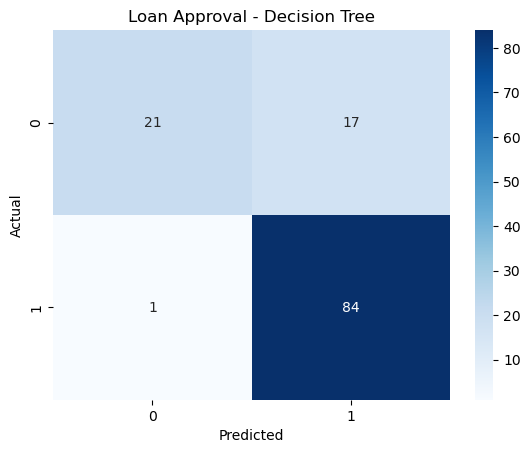

In [28]:
cm = confusion_matrix(y_val, y_pred)

print(cm)
import matplotlib.pyplot as plt
import seaborn as sns

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Loan Approval - Decision Tree")
plt.show()

In [29]:
print(classification_report(
    y_val,
    y_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



In [30]:
print(classification_report(
    y_val,
    y_pred,
    target_names=["Rejected", "Approved"]
))

              precision    recall  f1-score   support

    Rejected       0.95      0.55      0.70        38
    Approved       0.83      0.99      0.90        85

    accuracy                           0.85       123
   macro avg       0.89      0.77      0.80       123
weighted avg       0.87      0.85      0.84       123



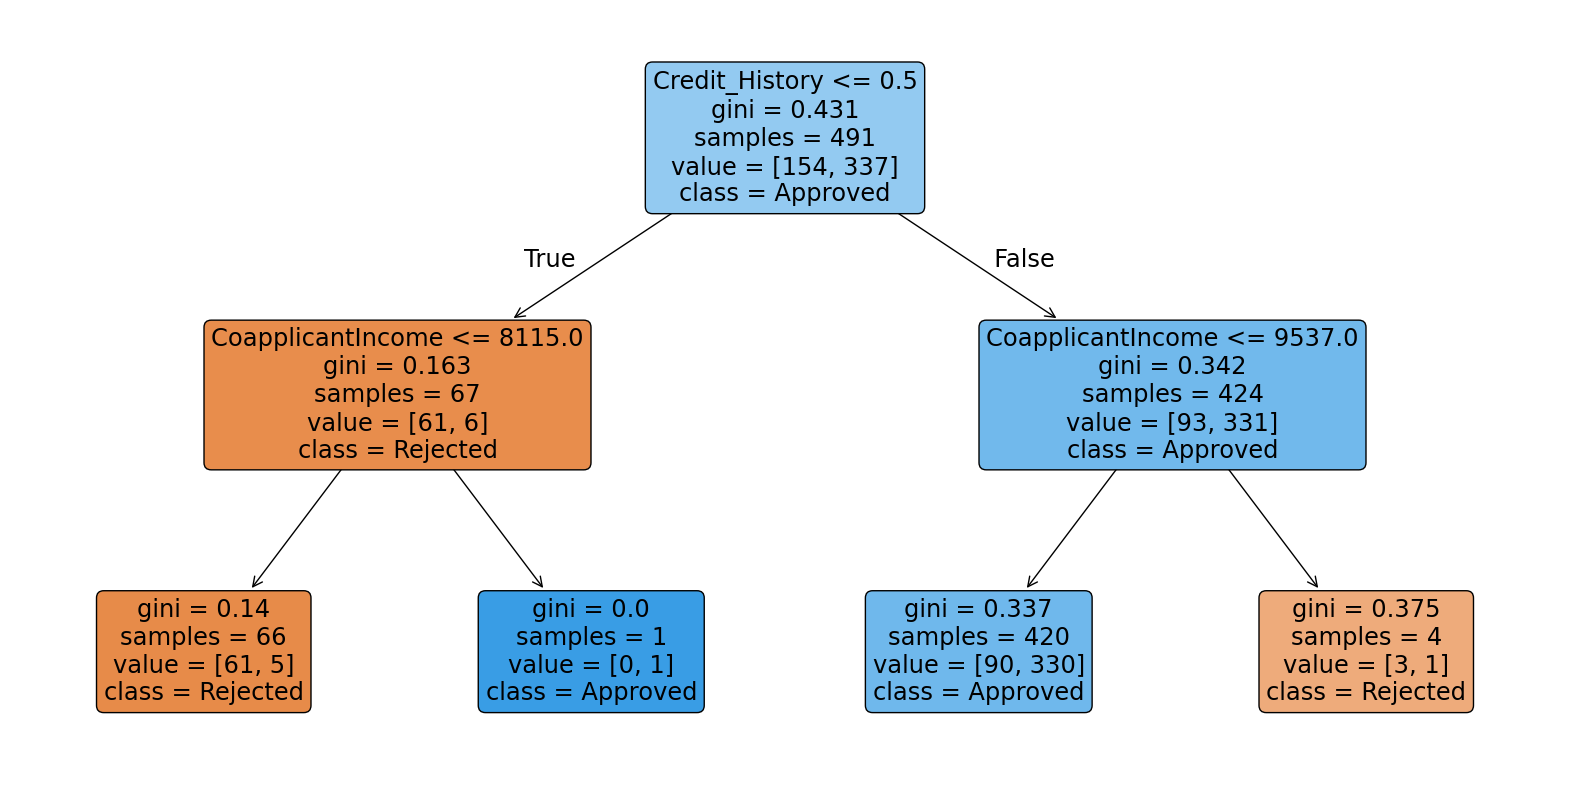

In [32]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Rejected", "Approved"],
    filled=True,
    rounded=True
)

plt.show()

In [33]:
#train for all dataset
final_model = DecisionTreeClassifier(
    max_depth=2,
    random_state=42
)

final_model.fit(X, y)

,criterion,'gini'
,splitter,'best'
,max_depth,2
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [34]:
test_predictions = final_model.predict(X_test)

In [35]:
test_predictions = np.where(
    test_predictions == 1,
    "Y",
    "N"
)

In [36]:
submission = pd.DataFrame({
    "Loan_ID": test_ids,
    "Loan_Status": test_predictions
})

In [37]:
print(submission.head(10))
print(submission.shape)

    Loan_ID Loan_Status
0  LP001015           Y
1  LP001022           Y
2  LP001031           Y
3  LP001035           Y
4  LP001051           Y
5  LP001054           Y
6  LP001055           Y
7  LP001056           N
8  LP001059           Y
9  LP001067           Y
(367, 2)


In [38]:
submission.to_csv("submission.csv", index=False)

In [39]:
import os

print(os.path.exists("submission.csv"))

True


In [40]:
print("Sample columns:", sample.columns.tolist())
print("Submission columns:", submission.columns.tolist())

print("Sample shape:", sample.shape)
print("Submission shape:", submission.shape)

Sample columns: ['Loan_ID', 'Loan_Status']
Submission columns: ['Loan_ID', 'Loan_Status']
Sample shape: (367, 2)
Submission shape: (367, 2)


In [41]:
print((sample["Loan_ID"] == submission["Loan_ID"]).all())

True


In [ ]:
## Github repository:


## Conclusion

A Decision Tree Classifier was successfully developed for loan approval prediction.

After preprocessing the data and testing different tree depths, a maximum depth of 2 provided the best validation performance with an accuracy of approximately **85.37%**.

The final model was trained on the complete training dataset and used to generate predictions for the test dataset. The predictions were saved in the required `submission.csv` format.

The results show that the Decision Tree can effectively predict loan approval status, although its ability to identify rejected loans can be further improved through additional feature engineering, class balancing, or alternative machine learning algorithms.

## Final Result

**Algorithm:** Decision Tree Classifier  
**Best `max_depth`:** 2  
**Validation Accuracy:** 85.37%  
**Prediction File:** `submission.csv`